In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
?pd.read_csv

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

In [4]:
from sklearn.datasets import make_blobs
from sklearn import svm

In [6]:
from imblearn.over_sampling import SVMSMOTE

In [8]:
dir(svm)

['LinearSVC',
 'LinearSVR',
 'NuSVC',
 'NuSVR',
 'OneClassSVM',
 'SVC',
 'SVR',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_bounds',
 '_classes',
 '_liblinear',
 '_libsvm',
 '_libsvm_sparse',
 'l1_min_c']

In [9]:
centers=[(0,0), (5,5)]
cluster_std = 1.5
n_features = 2
n_samples = 1600

In [11]:
X,y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=centers,
    cluster_std=cluster_std,
    random_state=0,
)

X,y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [12]:
y.value_counts()

0    800
1    800
Name: count, dtype: int64

In [13]:
data1 = X[y==0]
data2 = X[y==1].sample(200, random_state=42)

In [15]:
X = pd.concat([data1, data2], axis=0)

In [16]:
X.shape, y.shape

((1000, 2), (1600,))

In [18]:
y = y.loc[X.index]
X.shape, y.shape

((1000, 2), (1000,))

In [19]:
y.value_counts()

0    800
1    200
Name: count, dtype: int64

# Finding the Support Vectors

In [20]:
dir(svm)

['LinearSVC',
 'LinearSVR',
 'NuSVC',
 'NuSVR',
 'OneClassSVM',
 'SVC',
 'SVR',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_bounds',
 '_classes',
 '_liblinear',
 '_libsvm',
 '_libsvm_sparse',
 'l1_min_c']

In [21]:
from sklearn.svm import SVC

In [22]:
?SVC

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the

In [23]:
clf = SVC(
    kernel='linear',
    random_state=0,
)
clf.fit(X,y)

SVC(kernel='linear', random_state=0)

In [24]:
dir(clf)

['C',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_proba',
 '_compute_kernel',
 '_decision_function',
 '_dense_decision_function',
 '_dense_fit',
 '_dense_predict',
 '_dense_predict_proba',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_dual_coef_',
 '_estimator_type',
 '_gamma',
 '_get_coef',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_impl',
 '_inte

In [25]:
?clf.support_

Type:        ndarray
String form: [ 30  48  79 305 337 432 536 771 782 803 833 852 860 869 905 927 963]
Length:      17
File:        ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/numpy/__init__.py
Docstring:  
ndarray(shape, dtype=float, buffer=None, offset=0,
        strides=None, order=None)

An array object represents a multidimensional, homogeneous array
of fixed-size items.  An associated data-type object describes the
format of each element in the array (its byte-order, how many bytes it
occupies in memory, whether it is an integer, a floating point number,
or something else, etc.)

Arrays should be constructed using `array`, `zeros` or `empty` (refer
to the See Also section below).  The parameters given here refer to
a low-level method (`ndarray(...)`) for instantiating an array.

For more information, refer to the `numpy` module and examine the
methods and attributes of an array.

Parameters
----------
(for the __new__ method; see Notes below

In [26]:
help(clf.support_)

Help on ndarray object:

class ndarray(builtins.object)
 |  ndarray(shape, dtype=float, buffer=None, offset=0,
 |          strides=None, order=None)
 |  
 |  An array object represents a multidimensional, homogeneous array
 |  of fixed-size items.  An associated data-type object describes the
 |  format of each element in the array (its byte-order, how many bytes it
 |  occupies in memory, whether it is an integer, a floating point number,
 |  or something else, etc.)
 |  
 |  Arrays should be constructed using `array`, `zeros` or `empty` (refer
 |  to the See Also section below).  The parameters given here refer to
 |  a low-level method (`ndarray(...)`) for instantiating an array.
 |  
 |  For more information, refer to the `numpy` module and examine the
 |  methods and attributes of an array.
 |  
 |  Parameters
 |  ----------
 |  (for the __new__ method; see Notes below)
 |  
 |  shape : tuple of ints
 |      Shape of created array.
 |  dtype : data-type, optional
 |      Any objec

In [27]:
clf.support_

array([ 30,  48,  79, 305, 337, 432, 536, 771, 782, 803, 833, 852, 860,
       869, 905, 927, 963], dtype=int32)

In [28]:
len(clf.support_)

17

In [29]:
for item in dir(clf):
    if 'support' in item:
        print(item)

_n_support
n_support_
support_
support_vectors_


In [30]:
for item in dir(clf):
    if 'support' in item.lower():
        print(item)

_n_support
n_support_
support_
support_vectors_


In [31]:
dir(clf)

['C',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_proba',
 '_compute_kernel',
 '_decision_function',
 '_dense_decision_function',
 '_dense_fit',
 '_dense_predict',
 '_dense_predict_proba',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_dual_coef_',
 '_estimator_type',
 '_gamma',
 '_get_coef',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_impl',
 '_inte

In [32]:
import imblearn.over_sampling

In [33]:
dir(imblearn.over_sampling)

['ADASYN',
 'BorderlineSMOTE',
 'KMeansSMOTE',
 'RandomOverSampler',
 'SMOTE',
 'SMOTEN',
 'SMOTENC',
 'SVMSMOTE',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adasyn',
 '_random_over_sampler',
 '_smote',
 'base']

In [34]:
for item in dir(imblearn.over_sampling):
    if 'smote' in item.lower():
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE
_smote


In [35]:
for item in dir(clf):
    if 'support' in item.lower():
        print(item)

_n_support
n_support_
support_
support_vectors_


In [37]:
help(clf.support_vectors_)

Help on ndarray object:

class ndarray(builtins.object)
 |  ndarray(shape, dtype=float, buffer=None, offset=0,
 |          strides=None, order=None)
 |  
 |  An array object represents a multidimensional, homogeneous array
 |  of fixed-size items.  An associated data-type object describes the
 |  format of each element in the array (its byte-order, how many bytes it
 |  occupies in memory, whether it is an integer, a floating point number,
 |  or something else, etc.)
 |  
 |  Arrays should be constructed using `array`, `zeros` or `empty` (refer
 |  to the See Also section below).  The parameters given here refer to
 |  a low-level method (`ndarray(...)`) for instantiating an array.
 |  
 |  For more information, refer to the `numpy` module and examine the
 |  methods and attributes of an array.
 |  
 |  Parameters
 |  ----------
 |  (for the __new__ method; see Notes below)
 |  
 |  shape : tuple of ints
 |      Shape of created array.
 |  dtype : data-type, optional
 |      Any objec

In [38]:
help(clf)

Help on SVC in module sklearn.svm._classes object:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |  
 |  C-Support Vector Classification.
 |  
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |  
 |  The multiclass support is handled according to a one-vs-one scheme.
 |  
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `

<Axes: xlabel='varA', ylabel='varB'>

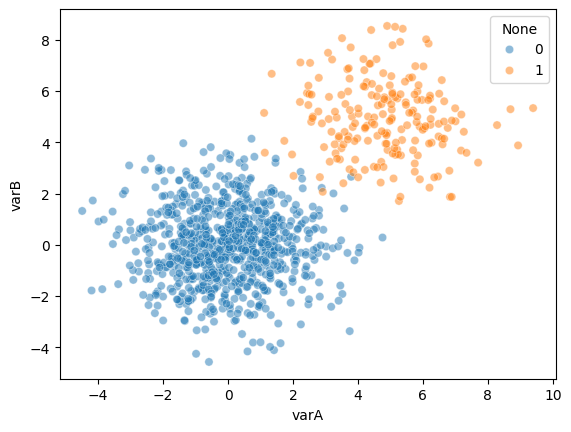

In [39]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)

In [40]:
clf.support_vectors_

array([[3.57471716, 1.41671923],
       [2.23237829, 2.84383376],
       [1.45880368, 3.20080237],
       [2.27999229, 2.57938396],
       [2.88441304, 2.22077219],
       [3.24485392, 2.00479192],
       [0.72167269, 4.13903267],
       [1.46810698, 3.3613398 ],
       [3.78955236, 2.65488208],
       [2.0160958 , 2.68916304],
       [3.54960337, 2.40240298],
       [2.91532847, 2.06948216],
       [1.73160272, 4.05552436],
       [1.13142388, 3.59373592],
       [3.1315128 , 3.2432145 ],
       [2.82729971, 2.64080532],
       [1.97068987, 3.5236865 ]])

In [43]:
?plt.scatter

Signature:
plt.scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs,
) -> 'PathCollection'
Docstring:
A scatter plot of *y* vs. *x* with varying marker size and/or color.

Parameters
----------
x, y : float or array-like, shape (n, )
    The data positions.

s : float or array-like, shape (n, ), optional
    The marker size in points**2 (typographic points are 1/72 in.).
    Default is ``rc

In [49]:
help(plt.scatter)

Help on function scatter in module matplotlib.pyplot:

scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None, *, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, colorizer: 'Colorizer | None' = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'
    A scatter plot of *y* vs. *x* with varying marker size and/or color.
    
    Parameters
    ----------
    x, y : float or array-like, shape (n, )
        The data positions.
    
    s : float or array-like, shape (n, ), optional
        The marker size in points**2 (typographic points are 1/72 in.).
        Default is ``rcPa

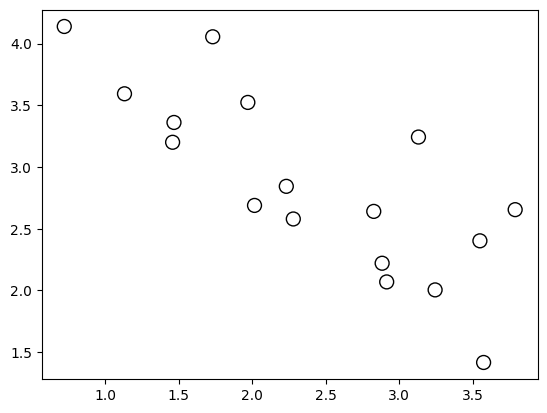

In [47]:
plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=100,
            facecolors='none',
            edgecolors='k')

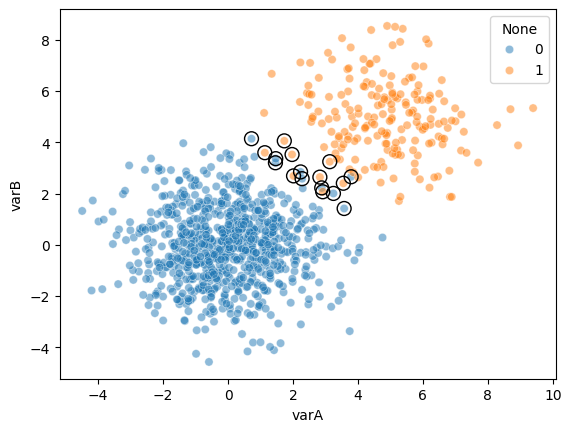

In [48]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)

plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=100,
            facecolors='none',
            edgecolors='k')

In [51]:
for item in dir(plt):
    if 'gca' in item.lower():
        print(item)

gca


In [52]:
?plt.gca

Signature: plt.gca() -> 'Axes'
Docstring:
Get the current Axes.

If there is currently no Axes on this Figure, a new one is created
using `.Figure.add_subplot`.  (To test whether there is currently an
Axes on a Figure, check whether ``figure.axes`` is empty.  To test
whether there is currently a Figure on the pyplot figure stack, check
whether `.pyplot.get_fignums()` is empty.)

Notes
-----

.. note::

    This is the :ref:`pyplot wrapper <pyplot_interface>` for `.Figure.gca`.
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py
Type:      function

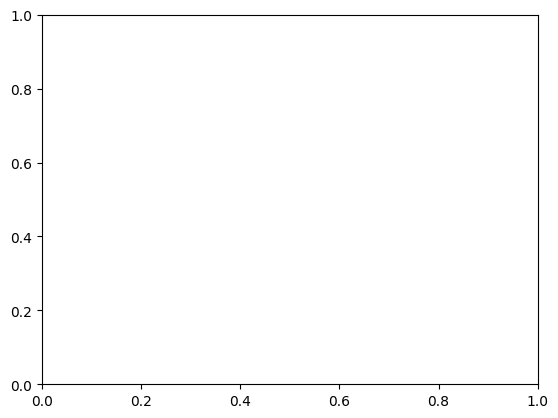

In [57]:
ax = plt.gca()

In [58]:
dir(ax)

['ArtistList',
 '_AxesBase__clear',
 '_PROPERTIES_EXCLUDED_FROM_SET',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_text',
 '_adjustable',
 '_agg_filter',
 '_alias_map',
 '_alpha',
 '_anchor',
 '_animated',
 '_aspect',
 '_autotitlepos',
 '_axes',
 '_axes_locator',
 '_axis_map',
 '_axis_names',
 '_axisbelow',
 '_box_aspect',
 '_callbacks',
 '_check_no_units',
 '_children',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_colorbars',
 '_convert_dx',
 '_current_image',
 '_different_canvas',
 '_errorevery_to_mask',
 '_facecolor',
 '_fill_between_process_units',
 '_fill_between_x_or_y',
 '_forward_navigation_events',
 '_

In [59]:
?ax.get_xlim

Signature: ax.get_xlim()
Docstring:
Return the x-axis view limits.

Returns
-------
left, right : (float, float)
    The current x-axis limits in data coordinates.

See Also
--------
.Axes.set_xlim
.Axes.set_xbound, .Axes.get_xbound
.Axes.invert_xaxis, .Axes.xaxis_inverted

Notes
-----
The x-axis may be inverted, in which case the *left* value will
be greater than the *right* value.
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/matplotlib/axes/_base.py
Type:      method

In [66]:
ax.get_xlim()[0]

np.float64(0.0)

In [62]:
ax.get_ylim()


(np.float64(0.0), np.float64(1.0))

In [67]:
clf.coef_

array([[1.09391748, 1.29738033]])

In [69]:
clf.intercept_[0]

np.float64(-6.748468539795875)

In [73]:
for item in dir(clf):
    if 'support' in item.lower():
        print(item)

_n_support
n_support_
support_
support_vectors_


In [74]:
clf.support_vectors_

array([[3.57471716, 1.41671923],
       [2.23237829, 2.84383376],
       [1.45880368, 3.20080237],
       [2.27999229, 2.57938396],
       [2.88441304, 2.22077219],
       [3.24485392, 2.00479192],
       [0.72167269, 4.13903267],
       [1.46810698, 3.3613398 ],
       [3.78955236, 2.65488208],
       [2.0160958 , 2.68916304],
       [3.54960337, 2.40240298],
       [2.91532847, 2.06948216],
       [1.73160272, 4.05552436],
       [1.13142388, 3.59373592],
       [3.1315128 , 3.2432145 ],
       [2.82729971, 2.64080532],
       [1.97068987, 3.5236865 ]])

In [75]:
?plt.scatter

Signature:
plt.scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs,
) -> 'PathCollection'
Docstring:
A scatter plot of *y* vs. *x* with varying marker size and/or color.

Parameters
----------
x, y : float or array-like, shape (n, )
    The data positions.

s : float or array-like, shape (n, ), optional
    The marker size in points**2 (typographic points are 1/72 in.).
    Default is ``rc

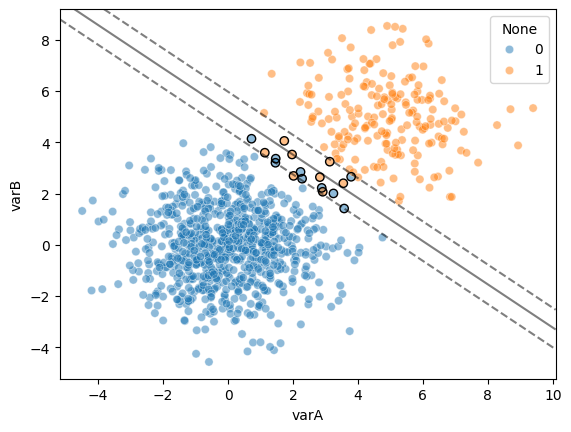

In [76]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)

plt.scatter(
    clf.support_vectors_[:,0],
    clf.support_vectors_[:,1],
    facecolors='none',
    edgecolors='k'
)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

x_min, x_max = xlim[0], xlim[1]
y_min, y_max = ylim[0], ylim[1]
size = 50 #The number of linearly space values

#Adding decision boundary
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, size),
    np.linspace(y_min, y_max, size)
)

#Decision functions
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], clf.coef_[0]) + clf.intercept_[0]
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1,0,1], alpha=0.5, linestyles=['--', '-', '--'])

In [77]:
?np.c_

Type:        CClass
String form: <numpy.lib._index_tricks_impl.CClass object at 0x7f2f880ac780>
Length:      0
File:        ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/numpy/lib/_index_tricks_impl.py
Docstring:  
Translates slice objects to concatenation along the second axis.

This is short-hand for ``np.r_['-1,2,0', index expression]``, which is
useful because of its common occurrence. In particular, arrays will be
stacked along their last axis after being upgraded to at least 2-D with
1's post-pended to the shape (column vectors made out of 1-D arrays).

See Also
--------
column_stack : Stack 1-D arrays as columns into a 2-D array.
r_ : For more detailed documentation.

Examples
--------
>>> import numpy as np
>>> np.c_[np.array([1,2,3]), np.array([4,5,6])]
array([[1, 4],
       [2, 5],
       [3, 6]])
>>> np.c_[np.array([[1,2,3]]), 0, 0, np.array([[4,5,6]])]
array([[1, 2, 3, ..., 4, 5, 6]])

In [79]:
xx.ravel().shape

(2500,)

In [81]:
np.c_[xx.ravel(), yy.ravel()].shape

(2500, 2)

In [86]:
clf.coef_[0].shape

(2,)

In [87]:
np.array([1,2,3]) + 2

array([3, 4, 5])

In [88]:
xx.shape

(50, 50)

# SMV SMOTE

In [89]:
for item in dir(imblearn.over_sampling):
    if 'smote' in item.lower():
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE
_smote


In [90]:
?SVMSMOTE

Init signature:
SVMSMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=None,
    out_step=0.5,
)
Docstring:     
Over-sampling using SVM-SMOTE.

Variant of SMOTE algorithm which use an SVM algorithm to detect sample to
use for generating new synthetic samples as proposed in [2]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.4

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

    

In [92]:
sm = SVMSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=SVC(kernel='linear'),
)

X_res, y_res = sm.fit_resample(X, y)

In [93]:
X.shape, X_res.shape

((1000, 2), (1600, 2))

In [94]:
y.value_counts(), y_res.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64)

In [95]:
from my_functions import Scatterplot

In [96]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

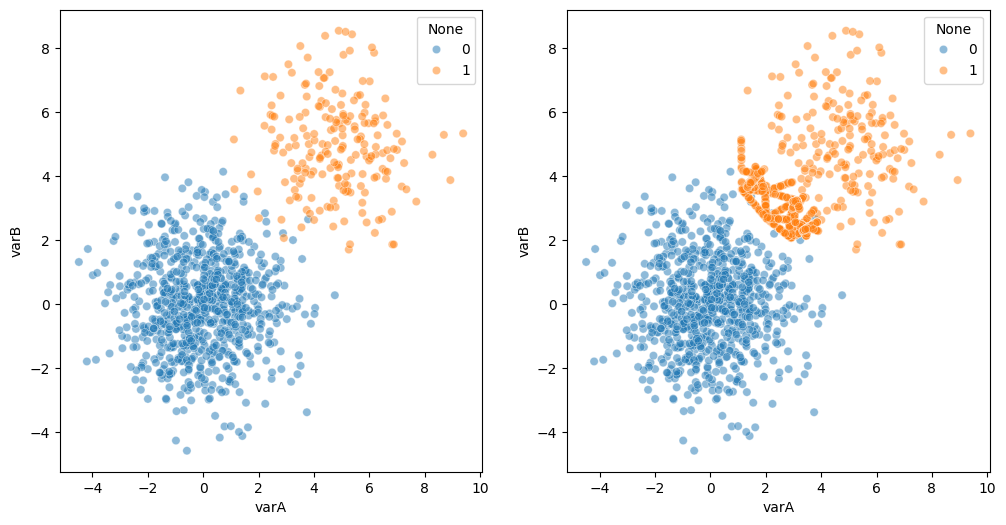

In [97]:
Scatterplot(X, y, X_res, y_res, alpha=0.5)

In [99]:
for item in dir(clf):
    if 'support' in item.lower():
        print(item)

_n_support
n_support_
support_
support_vectors_


In [103]:
?np.linspace

Signature:      
np.linspace(
    start,
    stop,
    num=50,
    endpoint=True,
    retstep=False,
    dtype=None,
    axis=0,
    *,
    device=None,
)
Call signature:  np.linspace(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function linspace at 0x7f2f88166950>
File:            ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/numpy/_core/function_base.py
Docstring:      
Return evenly spaced numbers over a specified interval.

Returns `num` evenly spaced samples, calculated over the
interval [`start`, `stop`].

The endpoint of the interval can optionally be excluded.

.. versionchanged:: 1.20.0
    Values are rounded towards ``-inf`` instead of ``0`` when an
    integer ``dtype`` is specified. The old behavior can
    still be obtained with ``np.linspace(start, stop, num).astype(int)``

Parameters
----------
start : array_like
    The starting value of the sequence.
stop : array_like
    The end value of the sequence,

In [104]:
?clf.coef_

Type:        property
String form: <property object at 0x7f2f183c8220>
Docstring:  
Weights assigned to the features when `kernel="linear"`.

Returns
-------
ndarray of shape (n_features, n_classes)

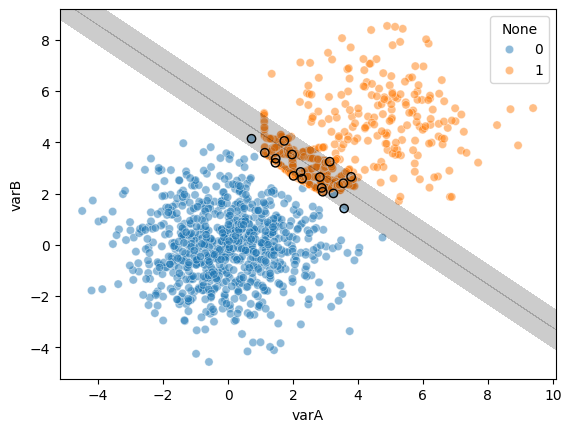

In [108]:
sns.scatterplot(
    data = X_res, x='varA', y='varB', hue=y_res, alpha=0.5
)

plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            facecolors='none',
            edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

x_min, x_max = xlim[0], xlim[1]
y_min, y_max = ylim[0], ylim[1]

#Adding the decision boundary
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 50),
    np.linspace(y_min, y_max, 50)
)

Z = np.dot(np.c_[xx.ravel(), yy.ravel()], clf.coef_[0]) + clf.intercept_[0]
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, colors='k', levels=[-1,0,1], alpha=0.2, linestyles=['--', '-', '--'])